Observations : 1350
Rats         : 90
TDS mean±SD  : 186.8 ± 150.1 mg/L
Gender ref   : female  (contrast: male)

Fitting...
  [Model 1 — Linear] converged: powell
  [Model 2 — Quadratic] converged: powell
  [Model 3 — Quad + Interaction] converged: powell

MODEL 1 — Linear TDS + Gender + Week
  Intercept                     β=+24.097  [+22.667,+25.528]  p=0.0000 ***
  Gender (male)                 β=+3.679  [+1.848,+5.509]  p=0.0001 ***
  TDS (linear)                  β=+0.551  [-0.365,+1.466]  p=0.2384 ns
  Week                          β=-1.917  [-1.993,-1.841]  p=0.0000 ***

  ICC = 0.309   AIC = 8944.9

MODEL 2 — Quadratic TDS + Gender + Week
  Intercept                     β=+24.422  [+22.737,+26.108]  p=0.0000 ***
  Gender (male)                 β=+3.679  [+1.854,+5.504]  p=0.0001 ***
  TDS (linear)                  β=+0.793  [-0.338,+1.924]  p=0.1693 ns
  TDS² (quadratic)              β=-0.325  [-1.221,+0.571]  p=0.4768 ns
  Week                          β=-1.917  [-1.993,-1.841

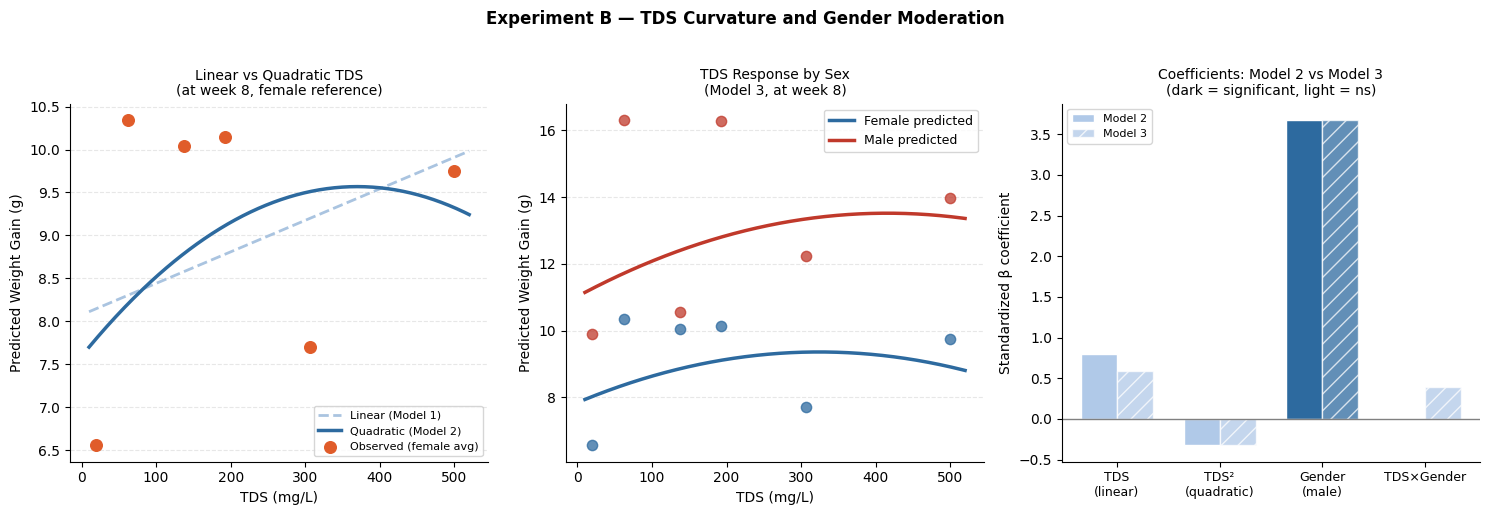

In [1]:
"""
Experiment B — Does the TDS–weight gain relationship curve, and does it differ by sex?
=======================================================================================
Model 1: weekly_weight_gain ~ TDS + gender + week + (1|rat)
Model 2: weekly_weight_gain ~ TDS + TDS² + gender + week + (1|rat)
Model 3: weekly_weight_gain ~ TDS + TDS² + gender + TDS:gender + week + (1|rat)

Built in steps so each addition is testable:
  M1 → M2 : Does adding TDS² improve fit? (tests curvature)
  M2 → M3 : Does adding TDS×gender improve fit? (tests sex difference in TDS response)

If TDS² significant → calculate optimal TDS = -β1 / (2β2)
If TDS×gender significant → male and female slopes differ
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 0.  LOAD & PREPARE
# ─────────────────────────────────────────────
df = pd.read_csv("data/processed_rat_data.csv")   # <── change path

TDS_MAP = {
    "Group 1 (RO water with < 20 TDS)":                                                             20,
    "Group 7 (RO water <20 with alternate day fasting (feed withdrawal))":                          20,
    "Group 2 (RO water with 50-75 TDS)":                                                            62.5,
    "Group 3 (RO water with 125 - 150 TDS)":                                                        137.5,
    "Group 11 (RO Water 125 - 150 TDS with alternate day fasting)":                                 137.5,
    "Group 4 (Telugu Ganga water supplied to Tirupati)":                                            192,
    "Group 5 (Kalyani Dam water supplied to Tirupati)":                                             306,
    "Group 8 (Kalyani Dam water supplied to Tirupati with alternate day fasting (feed withdrawal))": 306,
    "Group 9 (water prepared as per BIS)":                                                          500,
}

df["TDS_numeric"] = df["water_group"].map(TDS_MAP)
df_model = df.dropna(subset=["TDS_numeric"]).copy()
df_model["TDS_numeric"] = df_model["TDS_numeric"].astype(float)
df_model["week"]        = df_model["week"].astype(float)
df_model["gender"]      = df_model["gender"].astype("category")

# Standardize TDS to fix multicollinearity between TDS and TDS²
tds_mean = df_model["TDS_numeric"].mean()
tds_std  = df_model["TDS_numeric"].std()
df_model["TDS_z"]  = (df_model["TDS_numeric"] - tds_mean) / tds_std
df_model["TDS_sq"] = df_model["TDS_z"] ** 2

print(f"Observations : {len(df_model)}")
print(f"Rats         : {df_model['unique_rat_id'].nunique()}")
print(f"TDS mean±SD  : {tds_mean:.1f} ± {tds_std:.1f} mg/L")
genders = df_model["gender"].cat.categories.tolist()
print(f"Gender ref   : {genders[0]}  (contrast: {genders[1]})\n")

# ─────────────────────────────────────────────
# 1.  FIT THREE MODELS
# ─────────────────────────────────────────────
def fit(formula, label):
    for method in ["powell", "lbfgs", "nm", "bfgs"]:
        try:
            res = smf.mixedlm(
                formula, data=df_model,
                groups=df_model["unique_rat_id"]
            ).fit(method=method, reml=False, maxiter=1000)
            if res.converged:
                print(f"  [{label}] converged: {method}")
                return res
        except Exception:
            continue
    raise RuntimeError(f"{label} — no optimizer converged")

print("Fitting...")
m1 = fit("weekly_weight_gain ~ TDS_z + gender + week",                    "Model 1 — Linear")
m2 = fit("weekly_weight_gain ~ TDS_z + TDS_sq + gender + week",           "Model 2 — Quadratic")
m3 = fit("weekly_weight_gain ~ TDS_z + TDS_sq + gender + TDS_z:gender + week", "Model 3 — Quad + Interaction")
print()

# ─────────────────────────────────────────────
# 2.  RESULTS TABLES
# ─────────────────────────────────────────────
def sig(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"

rename = {
    "Intercept":              "Intercept",
    "TDS_z":                  "TDS (linear)",
    "TDS_sq":                 "TDS² (quadratic)",
    "gender[T.male]":         "Gender (male)",
    "TDS_z:gender[T.male]":   "TDS × Gender (male)",
    "week":                   "Week",
}

def summarise(result, label):
    print("=" * 62)
    print(label)
    print("=" * 62)
    params = result.fe_params
    pvals  = result.pvalues
    conf   = result.conf_int()
    for key in params.index:
        b    = params[key]
        p    = pvals[key]
        lo   = conf.loc[key, 0]
        hi   = conf.loc[key, 1]
        name = rename.get(key, key)
        print(f"  {name:<28}  β={b:+.3f}  [{lo:+.3f},{hi:+.3f}]  p={p:.4f} {sig(p)}")
    rand_var  = result.cov_re.values[0][0]
    icc = rand_var / (rand_var + result.scale)
    print(f"\n  ICC = {icc:.3f}   AIC = {result.aic:.1f}\n")

summarise(m1, "MODEL 1 — Linear TDS + Gender + Week")
summarise(m2, "MODEL 2 — Quadratic TDS + Gender + Week")
summarise(m3, "MODEL 3 — Quadratic TDS + Gender + TDS×Gender + Week")

# ─────────────────────────────────────────────
# 3.  MODEL COMPARISONS
# ─────────────────────────────────────────────
def lrt(m_null, m_alt, label, df_diff=1):
    stat  = 2 * (m_alt.llf - m_null.llf)
    p     = stats.chi2.sf(stat, df=df_diff)
    print(f"  {label}")
    print(f"    χ²({df_diff}) = {stat:.3f}   p = {p:.4f} {sig(p)}")
    print(f"    AIC: {m_null.aic:.1f} → {m_alt.aic:.1f}")
    return p

print("─" * 62)
print("MODEL COMPARISONS (Likelihood Ratio Tests)")
print("─" * 62)
p_quad   = lrt(m1, m2, "M1 → M2 : Does TDS² improve fit?  (curvature test)")
print()
p_inter  = lrt(m2, m3, "M2 → M3 : Does TDS×Gender improve fit?  (sex moderation)")
print()

# ─────────────────────────────────────────────
# 4.  KEY FINDINGS
# ─────────────────────────────────────────────
print("─" * 62)
print("KEY FINDINGS")
print("─" * 62)

# --- Curvature ---
b_tds2 = m2.fe_params["TDS_sq"]
p_tds2 = m2.pvalues["TDS_sq"]
print(f"\n  [1] CURVATURE (TDS²)  β={b_tds2:+.4f}  p={p_tds2:.4f} {sig(p_tds2)}")
if p_tds2 < 0.05:
    b_tds1   = m2.fe_params["TDS_z"]
    opt_std  = -b_tds1 / (2 * b_tds2)
    opt_real = opt_std * tds_std + tds_mean
    shape    = "inverted-U (peak exists)" if b_tds2 < 0 else "U-shaped (trough)"
    print(f"       Curve shape  : {shape}")
    print(f"       Optimal TDS  : {opt_real:.1f} mg/L")
    if opt_real < 20 or opt_real > 500:
        print(f"       ⚠  Outside experimental range — extrapolated value.")
    else:
        print(f"       ✓  Within experimental range (20–500 mg/L).")
else:
    opt_real = None
    print("       → No significant curvature. Linear relationship is sufficient.")
    print("       → Do not report an optimal TDS value.")

# --- Gender interaction ---
inter_key = "TDS_z:gender[T.male]"
b_inter = m3.fe_params.get(inter_key, np.nan)
p_inter_val = m3.pvalues.get(inter_key, np.nan)

# TDS slopes by sex from Model 3
b_tds_m3   = m3.fe_params["TDS_z"]
slope_f    = b_tds_m3
slope_m    = b_tds_m3 + b_inter
slope_f_raw = slope_f / tds_std * 100
slope_m_raw = slope_m / tds_std * 100

print(f"\n  [2] TDS × GENDER  β={b_inter:+.4f}  p={p_inter_val:.4f} {sig(p_inter_val)}")
print(f"       Female TDS slope : {slope_f:+.4f} std  =  {slope_f_raw:+.3f} g per 100 mg/L")
print(f"       Male   TDS slope : {slope_m:+.4f} std  =  {slope_m_raw:+.3f} g per 100 mg/L")
if p_inter_val < 0.05:
    print("       → TDS response DIFFERS significantly between sexes.")
else:
    print("       → TDS response does NOT differ significantly between sexes.")
    print("       → Use Model 2 (without interaction) as the final model.")

# --- Gender main effect ---
b_gender = m2.fe_params["gender[T.male]"]
p_gender = m2.pvalues["gender[T.male]"]
print(f"\n  [3] GENDER MAIN EFFECT  β={b_gender:+.3f}  p={p_gender:.4f} {sig(p_gender)}")
print(f"       Males gain {b_gender:+.2f} g/week more than females on average.")

# Best model recommendation
print("\n" + "─" * 62)
if p_inter_val < 0.05:
    print("  BEST MODEL: Model 3 (quadratic + gender interaction)")
elif p_tds2 < 0.05:
    print("  BEST MODEL: Model 2 (quadratic + gender, no interaction)")
else:
    print("  BEST MODEL: Model 1 (linear TDS + gender) — simpler is better here")

# ─────────────────────────────────────────────
# 5.  PLOT — 3 panels
# ─────────────────────────────────────────────
tds_range     = np.linspace(10, 520, 300)
tds_range_std = (tds_range - tds_mean) / tds_std
weeks         = np.arange(1, 16)
week_mid      = 8.0

tds_vals = [20, 62.5, 137.5, 192, 306, 500]
cmap     = plt.get_cmap("plasma")
colors   = [cmap(i / (len(tds_vals)-1)) for i in range(len(tds_vals))]

obs_wk = (df_model.groupby(["TDS_numeric","week"])["weekly_weight_gain"]
          .mean().reset_index())
obs_tds = (df_model.groupby(["TDS_numeric","gender"])["weekly_weight_gain"]
           .mean().reset_index())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1 — Linear vs quadratic TDS curve at mid-study week
ax = axes[0]
# Linear prediction (Model 1, gender=female at mid week)
pred_lin = (m1.fe_params["Intercept"] +
            m1.fe_params["TDS_z"] * tds_range_std +
            m1.fe_params["week"]  * week_mid)
# Quadratic prediction (Model 2, gender=female at mid week)
pred_quad = (m2.fe_params["Intercept"] +
             m2.fe_params["TDS_z"]  * tds_range_std +
             m2.fe_params["TDS_sq"] * tds_range_std**2 +
             m2.fe_params["week"]   * week_mid)

ax.plot(tds_range, pred_lin,  color="#aac4e0", linewidth=2,
        linestyle="--", label="Linear (Model 1)")
ax.plot(tds_range, pred_quad, color="#2d6a9f", linewidth=2.5,
        label="Quadratic (Model 2)")

# Observed group means (all weeks avg, female only to avoid overlap)
obs_f = obs_tds[obs_tds["gender"] == genders[0]]
ax.scatter(obs_f["TDS_numeric"], obs_f["weekly_weight_gain"],
           color="#e05c2a", s=70, zorder=5, label="Observed (female avg)")

if opt_real is not None and 10 <= opt_real <= 520:
    opt_s    = (opt_real - tds_mean) / tds_std
    pred_opt = (m2.fe_params["Intercept"] + m2.fe_params["TDS_z"]*opt_s +
                m2.fe_params["TDS_sq"]*opt_s**2 + m2.fe_params["week"]*week_mid)
    ax.axvline(opt_real, color="#2d9f5c", linewidth=1.5, linestyle=":",
               label=f"Optimal ≈ {opt_real:.0f} mg/L")
    ax.scatter([opt_real], [pred_opt], color="#2d9f5c", s=120, zorder=6, marker="*")

ax.set_xlabel("TDS (mg/L)", fontsize=10)
ax.set_ylabel("Predicted Weight Gain (g)", fontsize=10)
ax.set_title(f"Linear vs Quadratic TDS\n(at week {int(week_mid)}, female reference)", fontsize=10)
ax.legend(fontsize=8)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Panel 2 — Male vs Female TDS slopes (from Model 3)
ax2 = axes[1]
pred_f_m3 = (m3.fe_params["Intercept"] +
             m3.fe_params["TDS_z"]  * tds_range_std +
             m3.fe_params["TDS_sq"] * tds_range_std**2 +
             m3.fe_params["week"]   * week_mid)
b_gend = m3.fe_params.get("gender[T.male]", 0)
pred_m_m3 = pred_f_m3 + b_gend + b_inter * tds_range_std

ax2.plot(tds_range, pred_f_m3, color="#2d6a9f", linewidth=2.5, label=f"{genders[0].capitalize()} predicted")
ax2.plot(tds_range, pred_m_m3, color="#c0392b", linewidth=2.5, label=f"{genders[1].capitalize()} predicted")

for gender, color in zip(genders, ["#2d6a9f", "#c0392b"]):
    sub = obs_tds[obs_tds["gender"] == gender]
    ax2.scatter(sub["TDS_numeric"], sub["weekly_weight_gain"],
                color=color, s=55, alpha=0.75, zorder=5)

ax2.set_xlabel("TDS (mg/L)", fontsize=10)
ax2.set_ylabel("Predicted Weight Gain (g)", fontsize=10)
ax2.set_title(f"TDS Response by Sex\n(Model 3, at week {int(week_mid)})", fontsize=10)
ax2.legend(fontsize=9)
ax2.spines[["top","right"]].set_visible(False)
ax2.grid(axis="y", linestyle="--", alpha=0.3)

# Panel 3 — β coefficients across models (TDS, TDS², gender, interaction)
ax3 = axes[2]

param_labels = ["TDS\n(linear)", "TDS²\n(quadratic)", "Gender\n(male)", "TDS×Gender"]
m2_betas = [
    m2.fe_params.get("TDS_z",            np.nan),
    m2.fe_params.get("TDS_sq",           np.nan),
    m2.fe_params.get("gender[T.male]",   np.nan),
    np.nan,
]
m3_betas = [
    m3.fe_params.get("TDS_z",                  np.nan),
    m3.fe_params.get("TDS_sq",                 np.nan),
    m3.fe_params.get("gender[T.male]",         np.nan),
    m3.fe_params.get("TDS_z:gender[T.male]",   np.nan),
]
m2_ps = [
    m2.pvalues.get("TDS_z",            1),
    m2.pvalues.get("TDS_sq",           1),
    m2.pvalues.get("gender[T.male]",   1),
    1,
]
m3_ps = [
    m3.pvalues.get("TDS_z",                  1),
    m3.pvalues.get("TDS_sq",                 1),
    m3.pvalues.get("gender[T.male]",         1),
    m3.pvalues.get("TDS_z:gender[T.male]",   1),
]

x     = np.arange(len(param_labels))
width = 0.35

def bar_color(p):
    return "#2d6a9f" if p < 0.05 else "#b0c9e8"

bars2 = ax3.bar(x - width/2, m2_betas, width, label="Model 2",
                color=[bar_color(p) for p in m2_ps], edgecolor="white")
bars3 = ax3.bar(x + width/2, m3_betas, width, label="Model 3",
                color=[bar_color(p) for p in m3_ps], edgecolor="white",
                alpha=0.75, hatch="//")

ax3.axhline(0, color="gray", linewidth=1)
ax3.set_xticks(x)
ax3.set_xticklabels(param_labels, fontsize=9)
ax3.set_ylabel("Standardized β coefficient", fontsize=10)
ax3.set_title("Coefficients: Model 2 vs Model 3\n(dark = significant, light = ns)", fontsize=10)
ax3.legend(fontsize=8)
ax3.spines[["top","right"]].set_visible(False)

plt.suptitle("Experiment B — TDS Curvature and Gender Moderation",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/quadratic_model/quadratic_gender", dpi=150, bbox_inches="tight")
print("\nPlot saved → quadratic_gender.png")
plt.show()